# Model 2: ResNet18 Stem Late-Fusion 

This notebook is a cleaned training + evaluation flow for the selected baseline config.

## TODO:
- In section 4, there is some pretty aggressive operations on tags (partially remove adjectives). This is to reduce the number tags from ~100. There is room for improvement here, maybe even having some 2-level tag thing.
- In section 5, there is extreme data leakage, and we ignore this having the evaluation set being the whole dataset.
- In section 9, we have $
\text{rerank\_score}
=
\text{similarity}
+w_t\cdot \text{tag\_jaccard}
+w_y\cdot \text{year\_bonus}
-w_a\cdot \text{artist\_penalty},
$
where $(w_t, w_y, w_a)$ are config weights. Currently these weights were chosen a bit arbitrarily as `rerank_tag_weight`, `rerank_year_weight`, and `rerank_artist_repeat_penalty` in (2) `CFG`.


## Flow

1. Environment setup + config
2. Data loading + metadata helpers
3. Dataset + augmentation
4. Model definition
5. Loss functions
6. Training loop
7. Embedding build + retrieval (baseline and reranked)
8. Quick metrics
9. Artifact save + reload helpers


## System Flowchart (High Level)

```text
[Song spectrograms: mix + stems]
              |
              v
       [Shared ResNet18]
          /          \
         v            v
 [Mix embedding]  [Stem embeddings]
                     /      \
                    v        v
          [Harmonic path] [Drum path]
             (bass/other/vocals)
                  \      /
                   v    v
         [Late Fusion: mix + a*harmony + b*drums]
                           |
                           v
                    [Song embedding]
                      /         \
                     v           v
         [Symmetric InfoNCE] [Cosine retrieval]
           (training signal)   (top-k recs)
```


## 1) Environment Setup

This cell imports all dependencies used in training and evaluation.

- `torchvision.resnet18` is the shared encoder backbone.
- `TrackIndexer` and `load_png_resized` load mix/stem spectrograms.


In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision.models import ResNet18_Weights, resnet18


# Ensure `src/` is importable when running from notebooks or project root.
ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and ROOT_DIR.parent.exists():
    ROOT_DIR = ROOT_DIR.parent
SRC_DIR = ROOT_DIR / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from song_recommender.paths import DATA_DIR
from song_recommender.data.indexer import TrackIndexer
from song_recommender.data.loader import load_png_resized


## 2) Hyperparameters (Main Control Panel)

Edit this one cell for most experiments.

Recommended workflow:
- keep `experiment_name` + `run_label` unique per run
- change one or two knobs at a time
- keep seed fixed while comparing configs


In [3]:
# =========================
# Config (edit this cell)
# =========================
CFG = {
    # Name chosen for this cleaned notebook.
    "experiment_name": "resnet18_reco_base_v1",  # based on semantic_balance_v1 settings (reference run)
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Data
    "image_size": 224,
    "batch_size": 32,
    "num_workers": 0,

    # Optimization
    "num_epochs": 60,
    "max_steps_per_epoch": None,  # set int for quick probes
    "learning_rate": 8e-5,
    "weight_decay": 1e-5,
    "grad_clip_norm": 1.0,

    # Model
    "embedding_dim": 128,
    "projection_dim": 64,
    "pretrained": True,
    "stem_dropout_prob": 0.12,
    "fusion_alpha_init": 0.75,
    "drum_alpha_init": 0.20,

    # Augmentation
    "aug_enabled_train": True,
    "aug_pitch_shift_bins": 2,
    "aug_time_scale_range": (0.98, 1.02),
    "aug_gain_range": (0.98, 1.02),
    "aug_noise_std": 0.005,
    "aug_mask_prob": 0.15,
    "aug_max_mask_width": 8,
    "aug_one_second_dropout_prob": 0.03,
    "aug_one_second_width": 22,

    # Losses
    "nce_temperature": 0.12,
    "lambda_view_alignment": 0.05,
    "lambda_song_embed": 0.05,
    "lambda_song_nce": 0.50,
    "lambda_drum_align": 0.002,

    # Tag-aware negatives
    "use_tag_aware_negatives": False,
    "low_jaccard_threshold": 0.05,
    "random_negative_keep_prob": 0.70,

    # Soft-positive auxiliary
    "use_soft_positive_aux": True,
    "lambda_soft_positive": 0.02,
    "soft_pos_min_jaccard": 0.75,
    "soft_pos_min_tags": 2,
    "soft_pos_max_year_diff": 20,

    # Query + rerank
    # These reranking weights may introduce tag/year/artist bias.
    "query_spotify_id": "5kgvRTKmoJChOc5PAdHZg3",  # QOTSA - Keep Your Eyes Peeled
    "rerank_tag_weight": 0.12,
    "rerank_year_weight": 0.004,
    "rerank_artist_repeat_penalty": 0.03,

    # Quick metric evaluation (set None for full catalog)
    "metrics_max_queries": 2000,
    "metrics_sample_seed": 42,

    # Output
    "run_label": "model2_stem_late_fusion_resnet18_reco_base_v1",
}

OUTPUT_DIR = (DATA_DIR / "processed" / "model_runs" / CFG["run_label"]).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("experiment:", CFG["experiment_name"])
print("device:", CFG["device"])
print("output_dir:", OUTPUT_DIR)


experiment: resnet18_reco_base_v1
device: cuda
output_dir: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1


In [4]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Determinism improves comparability across runs (can reduce max throughput).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG["seed"])
device = torch.device(CFG["device"])


## 3) Data Load and Quick Sanity Check

Loads metadata and confirms stem ordering.

Expected stem order is:
`['bass', 'drums', 'other', 'vocals']`


In [5]:
# Load metadata and initialize indexer.
df = pd.read_parquet(DATA_DIR / "metadata.parquet")
indexer = TrackIndexer(df)

print("num songs:", len(df))
print("stem order:", ["full mix"] + indexer.stem_list)
df[["spotify_id", "artist", "name", "year", "tags"]].head(3)


num songs: 11239
stem order: ['full mix', 'bass', 'drums', 'other', 'vocals']


,spotify_id,artist,name,year,tags
0,0dnz7bSs3txd9nGY9e3Mlf,Rush,Limelight,2006,"classic_rock, hard_rock, 80s, progressive_rock"
1,0nvIhBnscX9w7P2yrqxB6K,Queen,Friends Will Be Friends,1986,"rock, classic_rock, hard_rock, 80s, british"
2,0a5wz1j3rnDa6IawNoZp5C,Cream,Tales of Brave Ulysses,2005,"rock, classic_rock, hard_rock, british, blues,..."


## 4) Metadata Helpers for Semantics

These functions normalize tags and create lookups used by:
- tag-aware negative filtering in InfoNCE
- soft-positive auxiliary loss (high tag overlap)


In [6]:
def canonicalize_tag(tag: str) -> str:
    t = str(tag).strip().lower().replace("-", "_").replace(" ", "_")
    if not t:
        return ""
    parts = [p for p in t.split("_") if p]
    if not parts:
        return ""

    # This is a bit aggressive, maybe allow for more tokens
    drop_tokens = {
        "classic", "modern", "alt", "alternative", "progressive", "neo", "post",
        "hard", "soft", "indie", "new", "old", "contemporary", "mainstream",
        "underground", "symphonic", "technical", "melodic", "ambient",
    }
    parts = [p for p in parts if p not in drop_tokens]
    if not parts:
        parts = [t.split("_")[-1]]

    alias = {
        "hiphop": "rap",
        "hip_hop": "rap",
        "rnb": "soul",
        "electronic": "electronica",
        "edm": "electronica",
    }
    return alias.get(parts[-1], parts[-1])


def parse_tag_set(value) -> set[str]:
    if pd.isna(value):
        return set()
    if isinstance(value, str):
        values = [v.strip() for v in value.split(",") if v.strip()]
    elif isinstance(value, (list, tuple, set)):
        values = [str(v).strip() for v in value if str(v).strip()]
    else:
        values = [str(value).strip()] if str(value).strip() else []

    parsed = {canonicalize_tag(v) for v in values}
    return {v for v in parsed if v}


def tag_jaccard(a_tags: set[str], b_tags: set[str]) -> float:
    if not a_tags and not b_tags:
        return 0.0
    union = a_tags | b_tags
    if not union:
        return 0.0
    return len(a_tags & b_tags) / len(union)


track_id_to_tags = {
    row["spotify_id"]: parse_tag_set(row.get("tags", ""))
    for _, row in df[["spotify_id", "tags"]].iterrows()
}

track_id_to_year = {
    row["spotify_id"]: (np.nan if pd.isna(row.get("year", np.nan)) else float(row.get("year")))
    for _, row in df[["spotify_id", "year"]].iterrows()
}

print("tag map built for tracks:", len(track_id_to_tags))
print("empty-tag tracks:", sum(len(v) == 0 for v in track_id_to_tags.values()))


tag map built for tracks: 11239
empty-tag tracks: 0


## 5) Dataset and Augmentation

- `SongAugmentation` applies synchronized global transforms to mix + stems.
- `StemContrastiveDataset` returns:
  - `mix`: `[1, H, W]`
  - `stems`: `[4, 1, H, W]`


In [7]:
class SongAugmentation:
    def __init__(
        self,
        pitch_shift_bins=2,
        time_scale_range=(0.98, 1.02),
        gain_range=(0.98, 1.02),
        noise_std=0.005,
        mask_prob=0.15,
        max_mask_width=8,
        one_second_dropout_prob=0.03,
        one_second_width=22,
        enabled=True,
    ):
        self.pitch_shift_bins = pitch_shift_bins
        self.time_scale_range = time_scale_range
        self.gain_range = gain_range
        self.noise_std = noise_std
        self.mask_prob = mask_prob
        self.max_mask_width = max_mask_width
        self.one_second_dropout_prob = one_second_dropout_prob
        self.one_second_width = one_second_width
        self.enabled = enabled

    def _time_scale(self, x, scale):
        _, h, w = x.shape
        new_w = max(8, int(round(w * scale)))
        x_scaled = F.interpolate(x.unsqueeze(0), size=(h, new_w), mode="bilinear", align_corners=False)
        x_scaled = F.interpolate(x_scaled, size=(h, w), mode="bilinear", align_corners=False)
        return x_scaled.squeeze(0)

    def _pitch_shift(self, x, shift):
        if shift == 0:
            return x
        return torch.roll(x, shifts=shift, dims=1)

    def _time_mask(self, x):
        if random.random() > self.mask_prob:
            return x
        _, _, w = x.shape
        mask_width = random.randint(1, self.max_mask_width)
        start = random.randint(0, max(0, w - mask_width))
        x = x.clone()
        x[:, :, start:start + mask_width] = 0.0
        return x

    def _long_time_dropout(self, x):
        if random.random() > self.one_second_dropout_prob:
            return x
        _, _, w = x.shape
        mask_width = min(self.one_second_width, w)
        start = random.randint(0, max(0, w - mask_width))
        x = x.clone()
        x[:, :, start:start + mask_width] = 0.0
        return x

    def __call__(self, mix, stems):
        if not self.enabled:
            return mix, stems

        shift = random.randint(-self.pitch_shift_bins, self.pitch_shift_bins)
        scale = random.uniform(*self.time_scale_range)
        gain = random.uniform(*self.gain_range)

        def apply(x):
            x = self._pitch_shift(x, shift)
            x = self._time_scale(x, scale)
            x = x * gain
            if self.noise_std > 0:
                x = x + torch.randn_like(x) * self.noise_std
            x = self._time_mask(x)
            x = self._long_time_dropout(x)
            return x.clamp(0.0, 1.0)

        mix = apply(mix)
        stems = torch.stack([apply(stem) for stem in stems], dim=0)
        return mix, stems


class StemContrastiveDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_size: int = 224, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.image_size = image_size
        self.transform = transform
        self.indexer = TrackIndexer(self.df)

    def __len__(self) -> int:
        return len(self.df)

    def _load_spec(self, path) -> torch.Tensor:
        array = load_png_resized(str(path), image_size=self.image_size)
        return torch.tensor(array, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        track_id = row["spotify_id"]
        spec_paths = self.indexer.get_spec_png_paths(track_id)

        mix = self._load_spec(spec_paths[0])
        stems = torch.stack([self._load_spec(path) for path in spec_paths[1:]], dim=0)

        if self.transform is not None:
            mix, stems = self.transform(mix, stems)

        return {"track_id": track_id, "mix": mix, "stems": stems}


In [8]:
train_augmentation = SongAugmentation(
    pitch_shift_bins=CFG["aug_pitch_shift_bins"],
    time_scale_range=CFG["aug_time_scale_range"],
    gain_range=CFG["aug_gain_range"],
    noise_std=CFG["aug_noise_std"],
    mask_prob=CFG["aug_mask_prob"],
    max_mask_width=CFG["aug_max_mask_width"],
    one_second_dropout_prob=CFG["aug_one_second_dropout_prob"],
    one_second_width=CFG["aug_one_second_width"],
    enabled=CFG["aug_enabled_train"],
)

eval_augmentation = SongAugmentation(enabled=False)

train_dataset = StemContrastiveDataset(df, image_size=CFG["image_size"], transform=train_augmentation)
eval_dataset = StemContrastiveDataset(df, image_size=CFG["image_size"], transform=eval_augmentation)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
)

batch = next(iter(train_loader))
print("train size:", len(train_dataset), "| eval size:", len(eval_dataset))
print("mix shape:", tuple(batch["mix"].shape))
print("stems shape:", tuple(batch["stems"].shape))


train size: 11239 | eval size: 11239
mix shape: (32, 1, 224, 224)
stems shape: (32, 4, 1, 224, 224)


## 6) Model: Stem Late-Fusion ResNet18

Core idea:
1. Encode mix and stems with the same ResNet18 encoder.
2. Build harmonic embedding from bass/other/vocals.
3. Keep drum embedding as a separate branch.
4. Fuse with learnable gates into final `song_embedding`.

Let $z=f_\theta(x)$ be our output embedded song, then
`z = normalize(m + alpha_h * h + alpha_d * d)`
where `m` is mix, `h` is harmonic stems, and `d` is drums.

- `alpha_h`, `alpha_d` are learned sigmoid gates in `(0, 1)`.
- `stem_logits` define a global stem prior that modulates harmonic/drum contribution.
- Contrastive loss uses projected views (`ProjectionHead`), while retrieval uses `song_embedding = z`.


In [9]:
class ProjectionHead(nn.Module):
    """Small MLP used only for the contrastive objective space."""
    def __init__(self, input_dim: int, projection_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(inplace=True),
            nn.Linear(input_dim, projection_dim),
        )

    def forward(self, x):
        return self.net(x)


class StemLateFusionResNet18(nn.Module):
    """
    Late-fusion encoder for mix + stems.

    Input shapes:
    - mix:   [B, 1, H, W]
    - stems: [B, 4, 1, H, W]
    """
    def __init__(
        self,
        embedding_dim=128,
        projection_dim=64,
        pretrained=True,
        fusion_alpha_init=0.7,
        drum_alpha_init=0.3,
        num_stems=4,
        stem_dropout_prob=0.1,
        harmonic_indices=(0, 2, 3),
        drum_index=1,
    ):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Linear(in_features, embedding_dim)

        self.encoder = backbone
        self.projection_head = ProjectionHead(embedding_dim, projection_dim)

        # Kept for checkpoint/log compatibility with earlier notebook naming.
        self.fusion_alpha_logit = nn.Parameter(torch.tensor(fusion_alpha_init, dtype=torch.float32).logit())
        self.drum_alpha_logit = nn.Parameter(torch.tensor(drum_alpha_init, dtype=torch.float32).logit())

        self.stem_logits = nn.Parameter(torch.zeros(num_stems, dtype=torch.float32))
        self.harmonic_logits = nn.Parameter(torch.zeros(len(harmonic_indices), dtype=torch.float32))

        self.harmonic_indices = tuple(harmonic_indices)
        self.drum_index = int(drum_index)
        self.stem_dropout_prob = stem_dropout_prob

    def _encode_inputs(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.encoder(x)

    def forward(self, mix, stems):
        batch_size, num_stems, channels, height, width = stems.shape

        # Encode full-mix and each stem in a shared embedding space.
        mix_embedding = self._encode_inputs(mix)
        # Flatten stems across batch so one encoder pass handles all stems.
        stem_inputs = stems.view(batch_size * num_stems, channels, height, width)
        stem_embeddings = self._encode_inputs(stem_inputs).view(batch_size, num_stems, -1)
        stem_embeddings = F.normalize(stem_embeddings, dim=2, eps=1e-8)

        stem_weights = torch.softmax(self.stem_logits, dim=0).unsqueeze(0).expand(batch_size, -1)

        # Stem dropout: regularizes fusion so the model does not over-rely on one stem.
        keep_mask = None
        if self.training and self.stem_dropout_prob > 0:
            keep_mask = (torch.rand(batch_size, num_stems, device=stems.device) > self.stem_dropout_prob).float()
            all_dropped = keep_mask.sum(dim=1, keepdim=True) == 0
            keep_mask = torch.where(all_dropped, torch.ones_like(keep_mask), keep_mask)
            stem_weights = stem_weights * keep_mask

        stem_weights = stem_weights / stem_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)

        # Harmonic branch uses bass/other/vocals by default.
        harm_idx = torch.tensor(self.harmonic_indices, device=stems.device, dtype=torch.long)
        harmonic_stems = stem_embeddings[:, harm_idx, :]
        harmonic_weights = torch.softmax(self.harmonic_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
        # Inject global stem prior so stem_logits directly influence harmonic fusion.
        harmonic_weights = harmonic_weights * stem_weights[:, harm_idx]
        all_harm_zero = harmonic_weights.sum(dim=1, keepdim=True) == 0
        harmonic_weights = torch.where(all_harm_zero, torch.ones_like(harmonic_weights), harmonic_weights)
        harmonic_weights = harmonic_weights / harmonic_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
        harmonic_embedding = torch.sum(harmonic_stems * harmonic_weights.unsqueeze(-1), dim=1)

        # Drum branch stays separate, then gets its own fusion gate.
        # Scale drum view by the same learned global stem prior.
        drum_embedding = stem_embeddings[:, self.drum_index, :] * stem_weights[:, self.drum_index].unsqueeze(-1)

        mix_embedding = F.normalize(mix_embedding, dim=1, eps=1e-8)
        harmonic_embedding = F.normalize(harmonic_embedding, dim=1, eps=1e-8)
        drum_embedding = F.normalize(drum_embedding, dim=1, eps=1e-8)

        # Learn scalar fusion gates in [0,1].
        alpha_h = torch.sigmoid(self.fusion_alpha_logit)
        alpha_d = torch.sigmoid(self.drum_alpha_logit)

        # Final late-fused song vector used for retrieval.
        song_embedding = F.normalize(
            mix_embedding + alpha_h * harmonic_embedding + alpha_d * drum_embedding,
            dim=1,
            eps=1e-8,
        )

        return {
            "mix_embedding": mix_embedding,
            "stem_embeddings": stem_embeddings,
            "fused_stem_embedding": harmonic_embedding,
            "harmonic_embedding": harmonic_embedding,
            "drum_embedding": drum_embedding,
            "stem_weights": stem_weights,
            "harmonic_weights": harmonic_weights,
            "song_embedding": song_embedding,
            "mix_projection": self.projection_head(mix_embedding),
            "stem_projection": self.projection_head(harmonic_embedding),
        }


## 7) Losses

Training objective combines:
- symmetric InfoNCE (mix projection vs harmonic projection)
- view alignment regularization
- song alignment regularization
- optional tag-based soft positives


## Overall Training Loss

$$
\mathcal L=\mathcal L_{\text{NCE}}+\lambda_{\text{song-nce}}\mathcal L_{\text{song-nce}}+\lambda_{\text{view}}(1-\cos(m,h))+\lambda_{\text{song}}\frac{(1-\cos(z,m))+(1-\cos(z,h))}{2}+\lambda_{\text{drum}}(1-\cos(z,d))+\lambda_{\text{soft}}\mathcal L_{\text{soft}}.
$$

$$
\mathcal L_{\text{NCE}}=\frac{\mathrm{CE}(\text{mix}\to\text{harmonic})+\mathrm{CE}(\text{harmonic}\to\text{mix})}{2},\quad \mathcal L_{\text{song-nce}}=\frac{\mathrm{CE}(z\to m)+\mathrm{CE}(m\to z)}{2}.
$$

$$
\mathcal L_{\text{soft}}=\operatorname*{mean}_{(i,j)\in\mathcal P}\left[w_{ij}(1-\cos(z_i,z_j))\right].
$$

`CE(\cdot)` denotes cross-entropy over in-batch similarity logits, with the diagonal pair as the target class for each query.

$m,h,d$: normalized mix/harmonic/drum embeddings; $z$: normalized fused song embedding.

If soft-positive is disabled (or $\mathcal P=\varnothing$), use $\lambda_{\text{soft}}\mathcal L_{\text{soft}}=0$.


In [10]:
def build_tag_negative_mask(track_ids, track_id_to_tags, low_jaccard_threshold=0.10):
    """Mask negatives to prefer low-overlap semantic pairs (by tags)."""
    n = len(track_ids)
    mask = torch.zeros((n, n), dtype=torch.bool)
    for i, ti in enumerate(track_ids):
        tags_i = track_id_to_tags.get(ti, set())
        for j, tj in enumerate(track_ids):
            if i == j:
                continue
            tags_j = track_id_to_tags.get(tj, set())
            if tag_jaccard(tags_i, tags_j) <= low_jaccard_threshold:
                mask[i, j] = True
    return mask


def symmetric_info_nce_loss(
    mix_projection,
    stem_projection,
    temperature=0.1,
    track_ids=None,
    track_id_to_tags=None,
    use_tag_aware_negatives=False,
    low_jaccard_threshold=0.10,
    random_negative_keep_prob=0.50,
):
    """Bidirectional InfoNCE with optional tag-aware negative filtering."""
    # Normalize projections before cosine-similarity logits.
    mix_projection = F.normalize(mix_projection, dim=1, eps=1e-8)
    stem_projection = F.normalize(stem_projection, dim=1, eps=1e-8)

    logits = (mix_projection @ stem_projection.T) / temperature
    n = logits.size(0)
    labels = torch.arange(n, device=logits.device)

    if use_tag_aware_negatives and track_ids is not None and track_id_to_tags is not None and n > 1:
        low_j_mask = build_tag_negative_mask(
            track_ids,
            track_id_to_tags=track_id_to_tags,
            low_jaccard_threshold=low_jaccard_threshold,
        ).to(logits.device)

        # Keep all low-Jaccard negatives plus a random subset of the rest.
        rand_mask = (torch.rand((n, n), device=logits.device) < random_negative_keep_prob)
        diag = torch.eye(n, device=logits.device, dtype=torch.bool)
        keep = low_j_mask | rand_mask | diag

        row_has_negative = (keep & ~diag).any(dim=1)
        if not row_has_negative.all():
            missing_rows = (~row_has_negative).nonzero(as_tuple=False).flatten()
            for r in missing_rows.tolist():
                keep[r, (r + 1) % n] = True

        logits = logits.masked_fill(~keep, -1e9)

    loss_mix_to_stems = F.cross_entropy(logits, labels)
    loss_stems_to_mix = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_mix_to_stems + loss_stems_to_mix)


def batch_soft_positive_loss(
    track_ids,
    song_embeddings,
    track_id_to_tags,
    track_id_to_year,
    min_jaccard=0.50,
    min_tags_per_song=2,
    max_year_diff=20,
):
    """Pull in-batch songs together when tags strongly agree (soft positives)."""
    n = len(track_ids)
    if n < 2:
        return song_embeddings.new_tensor(0.0), 0

    losses = []
    matches = 0

    for i in range(n):
        ti = track_ids[i]
        tags_i = track_id_to_tags.get(ti, set())
        if len(tags_i) < min_tags_per_song:
            continue
        yi = track_id_to_year.get(ti, np.nan)

        for j in range(i + 1, n):
            tj = track_ids[j]
            tags_j = track_id_to_tags.get(tj, set())
            if len(tags_j) < min_tags_per_song:
                continue

            jacc = tag_jaccard(tags_i, tags_j)
            if jacc < min_jaccard:
                continue

            yj = track_id_to_year.get(tj, np.nan)
            if not (np.isnan(yi) or np.isnan(yj)) and abs(yi - yj) > max_year_diff:
                continue

            w = (jacc - min_jaccard) / max(1e-8, (1.0 - min_jaccard))
            sim = F.cosine_similarity(song_embeddings[i:i+1], song_embeddings[j:j+1], dim=1, eps=1e-8)
            losses.append(w * (1.0 - sim))
            matches += 1

    if not losses:
        return song_embeddings.new_tensor(0.0), 0

    return torch.cat(losses, dim=0).mean(), matches


## 8) Training Loop

Given a batch of mix/stem spectrograms, the model produces
`m, h, d, z` and projected views for contrastive learning.

We optimize
$$
\mathcal L
=
\mathcal L_{\text{NCE}}
+\lambda_{\text{view}}(1-\cos(m,h))
+\lambda_{\text{song}}\frac{(1-\cos(z,m))+(1-\cos(z,h))}{2}
+\lambda_{\text{drum}}(1-\cos(z,d))
+\lambda_{\text{soft}}\mathcal L_{\text{soft}}.
$$

Then we run standard SGD-style update:
1. `zero_grad()`
2. `backward()`
3. gradient clipping
4. `optimizer.step()`

Per epoch, we step the cosine scheduler and log
`avg_loss`, learning rate, and fusion gates (`alpha_h`, `alpha_d`).


This runs one configured experiment and logs per-epoch:
- average loss
- learning rate
- harmonic/drum fusion alphas


In [11]:
def train_one_run(cfg, train_loader, track_id_to_tags, track_id_to_year, device):
    """Train one experiment run from CFG and return model + epoch history."""
    # Model follows the selected semantic-balance baseline settings.
    model = StemLateFusionResNet18(
        embedding_dim=cfg["embedding_dim"],
        projection_dim=cfg["projection_dim"],
        pretrained=cfg["pretrained"],
        fusion_alpha_init=cfg["fusion_alpha_init"],
        drum_alpha_init=cfg["drum_alpha_init"],
        stem_dropout_prob=cfg["stem_dropout_prob"],
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, cfg["num_epochs"]))

    # Training objective:
    #   nce + view_align + song_align + drum_align + optional soft_positive
    history = []
    for epoch in range(cfg["num_epochs"]):
        model.train()
        running = 0.0
        steps = 0
        epoch_random_cos_means = []
        epoch_random_cos_stds = []
        epoch_top10_cos_means = []
        epoch_top10_cos_stds = []

        for step, batch in enumerate(train_loader):
            if cfg["max_steps_per_epoch"] is not None and step >= cfg["max_steps_per_epoch"]:
                break

            mix = batch["mix"].to(device)
            stems = batch["stems"].to(device)
            outputs = model(mix, stems)

            # Main contrastive objective: mix view vs harmonic stem view.
            nce_loss = symmetric_info_nce_loss(
                outputs["mix_projection"],
                outputs["stem_projection"],
                temperature=cfg["nce_temperature"],
                track_ids=batch["track_id"],
                track_id_to_tags=track_id_to_tags,
                use_tag_aware_negatives=cfg["use_tag_aware_negatives"],
                low_jaccard_threshold=cfg["low_jaccard_threshold"],
                random_negative_keep_prob=cfg["random_negative_keep_prob"],
            )

            # Retrieval-space contrastive objective: directly trains song embedding geometry.
            song_nce_loss = symmetric_info_nce_loss(
                outputs["song_embedding"],
                outputs["mix_embedding"],
                temperature=cfg["nce_temperature"],
                track_ids=batch["track_id"],
                track_id_to_tags=track_id_to_tags,
                use_tag_aware_negatives=cfg["use_tag_aware_negatives"],
                low_jaccard_threshold=cfg["low_jaccard_threshold"],
                random_negative_keep_prob=cfg["random_negative_keep_prob"],
            )

            view_alignment_loss = 1.0 - F.cosine_similarity(
                outputs["mix_embedding"],
                outputs["harmonic_embedding"],
                dim=1,
                eps=1e-8,
            ).mean()

            song_mix_alignment_loss = 1.0 - F.cosine_similarity(
                outputs["song_embedding"],
                outputs["mix_embedding"],
                dim=1,
                eps=1e-8,
            ).mean()
            song_harm_alignment_loss = 1.0 - F.cosine_similarity(
                outputs["song_embedding"],
                outputs["harmonic_embedding"],
                dim=1,
                eps=1e-8,
            ).mean()
            song_embedding_loss = 0.5 * (song_mix_alignment_loss + song_harm_alignment_loss)

            song_drum_alignment_loss = 1.0 - F.cosine_similarity(
                outputs["song_embedding"],
                outputs["drum_embedding"],
                dim=1,
                eps=1e-8,
            ).mean()

            # Composite training objective (contrastive + alignment regularizers).
            loss = nce_loss
            loss = loss + cfg["lambda_song_nce"] * song_nce_loss
            loss = loss + cfg["lambda_view_alignment"] * view_alignment_loss
            loss = loss + cfg["lambda_song_embed"] * song_embedding_loss
            loss = loss + cfg["lambda_drum_align"] * song_drum_alignment_loss

            soft_positive_loss = mix.new_tensor(0.0)
            soft_positive_matches = 0
            # Optional metadata-guided pull for semantically similar songs.
            if cfg["use_soft_positive_aux"]:
                soft_positive_loss, soft_positive_matches = batch_soft_positive_loss(
                    track_ids=batch["track_id"],
                    song_embeddings=outputs["song_embedding"],
                    track_id_to_tags=track_id_to_tags,
                    track_id_to_year=track_id_to_year,
                    min_jaccard=cfg["soft_pos_min_jaccard"],
                    min_tags_per_song=cfg["soft_pos_min_tags"],
                    max_year_diff=cfg["soft_pos_max_year_diff"],
                )
                loss = loss + cfg["lambda_soft_positive"] * soft_positive_loss

            if not torch.isfinite(loss):
                raise ValueError(f"Non-finite loss at epoch={epoch+1}, step={step}: {loss.item()}")

            # Standard optimization step with gradient clipping for stability.
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip_norm"])
            optimizer.step()

            # Batch-level retrieval-space diagnostics to detect collapse early.
            with torch.no_grad():
                z = F.normalize(outputs["song_embedding"], dim=1, eps=1e-8)
                sim = z @ z.T
                bsz = sim.size(0)
                if bsz > 1:
                    eye = torch.eye(bsz, device=sim.device, dtype=torch.bool)
                    offdiag = sim[~eye]
                    epoch_random_cos_means.append(float(offdiag.mean().detach().cpu()))
                    epoch_random_cos_stds.append(float(offdiag.std(unbiased=False).detach().cpu()))

                    sim_masked = sim.masked_fill(eye, float("-inf"))
                    k_top = min(10, bsz - 1)
                    top_vals, _ = torch.topk(sim_masked, k=k_top, dim=1, largest=True, sorted=True)
                    top_vals = top_vals.reshape(-1)
                    epoch_top10_cos_means.append(float(top_vals.mean().detach().cpu()))
                    epoch_top10_cos_stds.append(float(top_vals.std(unbiased=False).detach().cpu()))

            running += float(loss.item())
            steps += 1

            if step % 50 == 0:
                print(
                    f"epoch {epoch+1} step {step:03d}/{len(train_loader)} | "
                    f"total={loss.item():.4f} nce={nce_loss.item():.4f} song_nce={song_nce_loss.item():.4f} "
                    f"view={view_alignment_loss.item():.4f} song={song_embedding_loss.item():.4f} "
                    f"drum={song_drum_alignment_loss.item():.4f} soft={soft_positive_loss.item():.4f} ({soft_positive_matches})"
                )

        scheduler.step()
        avg_loss = running / max(steps, 1)
        harmonic_alpha = float(torch.sigmoid(model.fusion_alpha_logit).detach().cpu())
        drum_alpha = float(torch.sigmoid(model.drum_alpha_logit).detach().cpu())
        epoch_random_cos_mean = float(np.mean(epoch_random_cos_means)) if epoch_random_cos_means else np.nan
        epoch_random_cos_std = float(np.mean(epoch_random_cos_stds)) if epoch_random_cos_stds else np.nan
        epoch_top10_cos_mean = float(np.mean(epoch_top10_cos_means)) if epoch_top10_cos_means else np.nan
        epoch_top10_cos_std = float(np.mean(epoch_top10_cos_stds)) if epoch_top10_cos_stds else np.nan

        history.append(
            {
                "epoch": epoch + 1,
                "avg_loss": avg_loss,
                "lr": optimizer.param_groups[0]["lr"],
                "harmonic_alpha": harmonic_alpha,
                "drum_alpha": drum_alpha,
                "random_cos_mean": epoch_random_cos_mean,
                "random_cos_std": epoch_random_cos_std,
                "top10_cos_mean": epoch_top10_cos_mean,
                "top10_cos_std": epoch_top10_cos_std,
            }
        )
        print(
            f"epoch {epoch+1} done | avg_loss={avg_loss:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | alpha_h={harmonic_alpha:.4f} | alpha_d={drum_alpha:.4f} | "
            f"rand_cos={epoch_random_cos_mean:.4f}±{epoch_random_cos_std:.4f} | "
            f"top10_cos={epoch_top10_cos_mean:.4f}±{epoch_top10_cos_std:.4f}"
        )

    return model, pd.DataFrame(history)


In [12]:
model, train_history = train_one_run(
    cfg=CFG,
    train_loader=train_loader,
    track_id_to_tags=track_id_to_tags,
    track_id_to_year=track_id_to_year,
    device=device,
)

train_history


epoch 1 step 000/352 | total=4.3987 nce=3.4414 song_nce=1.8863 view=0.2125 song=0.0576 drum=0.2811 soft=0.0000 (0)
epoch 1 step 050/352 | total=1.5564 nce=1.4267 song_nce=0.2121 view=0.2755 song=0.0789 drum=0.5088 soft=0.2439 (2)
epoch 1 step 100/352 | total=1.0741 nce=0.9282 song_nce=0.2406 view=0.2518 song=0.0711 drum=0.5917 soft=0.4146 (2)
epoch 1 step 150/352 | total=0.9165 nce=0.7923 song_nce=0.1982 view=0.2721 song=0.0785 drum=0.5615 soft=0.3239 (1)
epoch 1 step 200/352 | total=0.7138 nce=0.6100 song_nce=0.1388 view=0.2356 song=0.0669 drum=0.5713 soft=0.9047 (2)
epoch 1 step 250/352 | total=0.4799 nce=0.3957 song_nce=0.1169 view=0.2129 song=0.0611 drum=0.6125 soft=0.5456 (2)
epoch 1 step 300/352 | total=0.5849 nce=0.4864 song_nce=0.1152 view=0.2361 song=0.0676 drum=0.6386 soft=1.2228 (1)
epoch 1 step 350/352 | total=0.5787 nce=0.5090 song_nce=0.1078 view=0.2274 song=0.0657 drum=0.5795 soft=0.0000 (0)
epoch 1 done | avg_loss=0.9646 | lr=7.99e-05 | alpha_h=0.7473 | alpha_d=0.1980 |

,epoch,avg_loss,lr,harmonic_alpha,drum_alpha,random_cos_mean,random_cos_std,top10_cos_mean,top10_cos_std
0,1,0.964641,7.994518e-05,0.747335,0.197982,0.122443,0.251319,0.406859,0.153660
1,2,0.314172,7.978088e-05,0.744613,0.195477,0.001985,0.231732,0.263928,0.156866
2,3,0.238369,7.950753e-05,0.741373,0.192462,-0.013815,0.218699,0.232915,0.151924
3,4,0.198994,7.912590e-05,0.737653,0.189035,-0.017002,0.209154,0.218835,0.147532
4,5,0.175582,7.863703e-05,0.733604,0.185192,-0.019592,0.203699,0.209232,0.144356
5,6,0.155000,7.804226e-05,0.729387,0.181487,-0.021304,0.197115,0.199796,0.140632
6,7,0.147455,7.734322e-05,0.724894,0.177945,-0.022127,0.193923,0.194636,0.138676
7,8,0.138628,7.654182e-05,0.720176,0.174470,-0.022217,0.190271,0.190110,0.137687
8,9,0.129765,7.564026e-05,0.715467,0.171195,-0.023409,0.186961,0.184980,0.133799
9,10,0.121079,7.464102e-05,0.710734,0.168010,-0.023974,0.183447,0.179793,0.132539


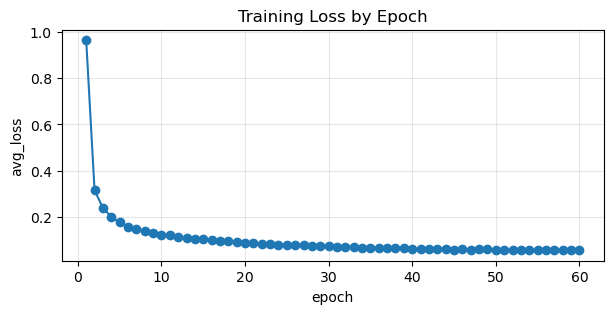

In [18]:
plt.figure(figsize=(7, 3))
plt.plot(train_history["epoch"], train_history["avg_loss"], marker="o")
plt.title("Training Loss by Epoch")
plt.xlabel("epoch")
plt.ylabel("avg_loss")
plt.grid(alpha=0.3)
plt.show()


## 9) Embedding Build and Retrieval Helpers

After training, we freeze the model and encode the catalog once into normalized `song_embedding` vectors.

For a query song:
1. **Baseline**: rank by cosine similarity in embedding space.
2. **Reranked**: rescore top cosine candidates with metadata priors (tag overlap, year proximity, artist-repeat penalty).

This keeps retrieval modular:
- the model learns representation geometry,
- reranking applies lightweight policy on top.



### Reranking Details

Starting from the top cosine candidate pool, we compute:
- `tag_jaccard`: overlap between query tags and candidate tags,
- `year_bonus`: negative year distance (closer years score higher),
- `artist_penalty`: 1 if same artist as query, else 0.

Final score:
$$
\text{rerank\_score}
=
\text{similarity}
+w_t\cdot \text{tag\_jaccard}
+w_y\cdot \text{year\_bonus}
-w_a\cdot \text{artist\_penalty},
$$
where $(w_t, w_y, w_a)$ are config weights.

We then sort by `rerank_score` and keep the top-$k$ results.


In [14]:
# Build normalized embeddings once, then run fast cosine retrieval.
@torch.no_grad()
def build_song_embeddings(model, loader, device):
    """Encode the full catalog into normalized embedding matrices."""
    model.eval()
    track_ids = []
    song_embeddings = []
    mix_embeddings = []
    stem_embeddings = []

    for batch in loader:
        mix = batch["mix"].to(device)
        stems = batch["stems"].to(device)
        out = model(mix, stems)

        track_ids.extend(batch["track_id"])
        song_embeddings.append(F.normalize(out["song_embedding"], dim=1, eps=1e-8).cpu())
        mix_embeddings.append(F.normalize(out["mix_embedding"], dim=1, eps=1e-8).cpu())
        stem_embeddings.append(F.normalize(out["fused_stem_embedding"], dim=1, eps=1e-8).cpu())

    return {
        "track_ids": track_ids,
        "song_embeddings": torch.cat(song_embeddings, dim=0).numpy(),
        "mix_embeddings": torch.cat(mix_embeddings, dim=0).numpy(),
        "stem_embeddings": torch.cat(stem_embeddings, dim=0).numpy(),
    }


def topk_cosine(embeddings, query_vec, k=10, exclude_idx=None):
    """Return top-k indices and cosine similarities for one query vector."""
    emb = torch.as_tensor(embeddings, dtype=torch.float32)
    q = torch.as_tensor(query_vec, dtype=torch.float32)

    if emb.ndim != 2 or q.ndim != 1:
        raise ValueError(f"Expected emb=[N,D], q=[D]; got {tuple(emb.shape)} and {tuple(q.shape)}")
    if emb.shape[1] != q.shape[0]:
        raise ValueError(f"Dimension mismatch: {emb.shape[1]} vs {q.shape[0]}")
    if not torch.isfinite(emb).all() or not torch.isfinite(q).all():
        raise ValueError("Non-finite values in embeddings/query_vec")

    # Use torch matmul for stable, warning-free cosine scoring.
    sims = torch.matmul(emb, q)

    if exclude_idx is not None:
        sims[exclude_idx] = float("-inf")

    k = min(int(k), int(sims.numel()))
    top_vals, top_idx = torch.topk(sims, k=k, largest=True, sorted=True)
    return top_idx.cpu().numpy(), top_vals.cpu().numpy()


def recommend_from_query(embedding_df, emb, query_spotify_id, k=10):
    """Baseline cosine retrieval for one query song id."""
    query_idx = embedding_df.index[embedding_df["spotify_id"] == query_spotify_id][0]
    query_vec = emb[query_idx]
    idx, scores = topk_cosine(emb, query_vec, k=k, exclude_idx=query_idx)
    recs = embedding_df.iloc[idx].copy()
    recs["similarity"] = scores
    return query_idx, query_vec, recs


def recommend_from_query_reranked(embedding_df, emb, query_spotify_id, k=10, candidate_pool=100):
    """Cosine retrieval with lightweight metadata reranking."""
    query_idx, _, recs = recommend_from_query(embedding_df, emb, query_spotify_id, k=candidate_pool)
    qrow = embedding_df.iloc[query_idx]
    qtags = parse_tag_set(qrow.get("tags", ""))

    recs = recs.copy()
    recs["tag_jaccard"] = recs["tags"].apply(lambda t: tag_jaccard(qtags, parse_tag_set(t)))
    recs["year_bonus"] = -recs["year"].apply(lambda y: 0.0 if pd.isna(y) or pd.isna(qrow.get("year", np.nan)) else abs(float(y) - float(qrow["year"])))
    recs["artist_penalty"] = (recs["artist"] == qrow["artist"]).astype(float)

    recs["rerank_score"] = (
        recs["similarity"]
        + CFG["rerank_tag_weight"] * recs["tag_jaccard"]
        + CFG["rerank_year_weight"] * recs["year_bonus"]
        - CFG["rerank_artist_repeat_penalty"] * recs["artist_penalty"]
    )
    recs = recs.sort_values("rerank_score", ascending=False).head(k)
    return query_idx, emb[query_idx], recs


In [15]:
embedding_out = build_song_embeddings(model, eval_loader, device)
track_ids = embedding_out["track_ids"]
song_embeddings = embedding_out["song_embeddings"]
mix_embeddings = embedding_out["mix_embeddings"]
stem_embeddings = embedding_out["stem_embeddings"]

embedding_df = df[["spotify_id", "artist", "name", "tags", "year"]].copy()
embedding_df = embedding_df.set_index("spotify_id").loc[track_ids].reset_index()

query_id = CFG["query_spotify_id"]
if query_id not in set(embedding_df["spotify_id"]):
    raise ValueError(f"Query id not found in embedding_df: {query_id}")
_, _, recs_base = recommend_from_query(embedding_df, song_embeddings, query_id, k=10)
_, _, recs_rerank = recommend_from_query_reranked(embedding_df, song_embeddings, query_id, k=10, candidate_pool=100)

query_row = embedding_df.loc[embedding_df["spotify_id"] == query_id].iloc[0]
print("query:", query_row["artist"], "-", query_row["name"])
print("\nBaseline top-10")
display(recs_base[["artist", "name", "spotify_id", "similarity"]])

print("\nReranked top-10")
display(recs_rerank[["artist", "name", "spotify_id", "similarity", "rerank_score"]])


query: Queens of the Stone Age - Keep Your Eyes Peeled

Baseline top-10


,artist,name,spotify_id,similarity
10168,Black Sabbath,Sabbra Cadabra,1OeorVexvWzr5ydkSknoYp,0.897589
2470,The Decemberists,When the War Came,0V7VYZiDt2kNO4WAhXXyxU,0.888334
2248,Sonic Youth,Pattern Recognition,0nVsFQPD4J5D1UMjkv35r2,0.879260
8387,Pain of Salvation,Fandango,023iI6YqDZp3UAfhqUCYz0,0.879051
2973,Ryan Adams,The Rescue Blues,04PcsabMnINgw71KDICtVd,0.871159
805,Billy Idol,Flesh for Fantasy,0ETbFWIFdVK8UQhM1UWzUJ,0.865118
7583,Opus,Live Is Life,03jRkPjMQB60INadf1TmoF,0.864881
10359,Misfits,Halloween II,3U710HGM7joCEAqImf6fFd,0.863157
10501,The Source,You Got the Love,2B3TyubiuLg17v6wQLbYNS,0.862488
7251,Savage Garden,Affirmation,09qj0RJJQjN8WAytUjwCCK,0.859214



Reranked top-10


,artist,name,spotify_id,similarity,rerank_score
8059,Rush,Far Cry,1YRMeATiALlDmxcAyZeLin,0.831309,0.935309
10925,Aerosmith,Back Back Train,0jc2NC9SrWv9k9S8ZUaKVV,0.830612,0.914612
10359,Misfits,Halloween II,3U710HGM7joCEAqImf6fFd,0.863157,0.899157
805,Billy Idol,Flesh for Fantasy,0ETbFWIFdVK8UQhM1UWzUJ,0.865118,0.897118
8387,Pain of Salvation,Fandango,023iI6YqDZp3UAfhqUCYz0,0.879051,0.895051
8217,Peter Gabriel,Intruder,0L9WPQs7Dg4GyHRGrNlUqm,0.781528,0.893528
2470,The Decemberists,When the War Came,0V7VYZiDt2kNO4WAhXXyxU,0.888334,0.884334
811,Tom Cochrane,Life Is a Highway,0DWmEwVPGJh2DxHFOTISqH,0.830481,0.882481
4220,White Rabbits,Percussion Gun,0q8PPzBm1ge1x6bp5q9NQE,0.854087,0.882087
2248,Sonic Youth,Pattern Recognition,0nVsFQPD4J5D1UMjkv35r2,0.879260,0.860403


## 10) Lightweight Quality Checks

These are quick diagnostics for iteration speed:
- `artist_hit@10`
- `genre_hit@10`

For final reporting, keep your richer evaluation notebook metrics too.

Tip: tune runtime via `CFG['metrics_max_queries']` (set `None` for full-catalog metrics).


In [16]:
def _sample_eval_df(embedding_df, max_queries=None, seed=42):
    """Optionally subsample queries for faster metric iteration."""
    if max_queries is None or max_queries >= len(embedding_df):
        return embedding_df
    return embedding_df.sample(max_queries, random_state=seed).reset_index(drop=True)


def artist_hit_at_k(embedding_df, emb, k=10, max_queries=None, seed=42):
    """Fraction of queries with at least one same-artist hit in top-k."""
    eval_df = _sample_eval_df(embedding_df, max_queries=max_queries, seed=seed)
    hits = []
    for _, row in eval_df.iterrows():
        qid = row["spotify_id"]
        _, _, recs = recommend_from_query(embedding_df, emb, qid, k=k)
        hits.append(float((recs["artist"] == row["artist"]).any()))
    return float(np.mean(hits))


def genre_hit_at_k(embedding_df, emb, k=10, max_queries=None, seed=42):
    """Fraction of queries with any overlapping-tag hit in top-k."""
    eval_df = _sample_eval_df(embedding_df, max_queries=max_queries, seed=seed)
    hits = []
    for _, row in eval_df.iterrows():
        qid = row["spotify_id"]
        qtags = parse_tag_set(row.get("tags", ""))
        _, _, recs = recommend_from_query(embedding_df, emb, qid, k=k)
        overlap = any(len(qtags & parse_tag_set(t)) > 0 for t in recs["tags"].tolist())
        hits.append(float(overlap))
    return float(np.mean(hits))


metrics = pd.DataFrame(
    {
        "metric": ["artist_hit@10", "genre_hit@10"],
        "value": [
            artist_hit_at_k(
                embedding_df,
                song_embeddings,
                k=10,
                max_queries=CFG['metrics_max_queries'],
                seed=CFG["metrics_sample_seed"],
            ),
            genre_hit_at_k(
                embedding_df,
                song_embeddings,
                k=10,
                max_queries=CFG['metrics_max_queries'],
                seed=CFG["metrics_sample_seed"],
            ),
        ],
    }
)
metrics


print(f"metric queries evaluated: {min(len(embedding_df), CFG['metrics_max_queries'] or len(embedding_df))}")


metric queries evaluated: 2000


## Run Summary

- Configuration authority: all run-time knobs are defined in `CFG`; edits should be made there before rerunning.
- Current reference run: `resnet18_reco_base_v1` with checkpoint, embedding matrix, and manifest persisted under `run_label`.
- Retrieval outputs reported here: cosine top-k and metadata-reranked top-k for the configured query ID.
- Metric scope note: quick metrics are currently computed on the same catalog used for training embeddings, so they are diagnostic (not holdout generalization estimates).


## 11) Artifact Saving

This persists everything needed for reuse:
- model checkpoint
- embedding matrix file
- run manifest with config + summary metrics


In [17]:
# Save artifacts for reuse.
checkpoint_path = OUTPUT_DIR / "checkpoint.pt"
embeddings_path = OUTPUT_DIR / "embeddings.npz"
manifest_path = OUTPUT_DIR / "run_manifest.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "embedding_dim": CFG["embedding_dim"],
        "projection_dim": CFG["projection_dim"],
        "cfg": CFG,
        "train_history": train_history.to_dict(orient="records"),
    },
    checkpoint_path,
)

np.savez(
    embeddings_path,
    song_embeddings=song_embeddings.astype(np.float32),
    mix_embeddings=mix_embeddings.astype(np.float32),
    stem_embeddings=stem_embeddings.astype(np.float32),
    spotify_id=np.array(track_ids, dtype=object),
)

manifest = {
    "saved_at": datetime.now().isoformat(timespec="seconds"),
    "experiment_name": CFG["experiment_name"],
    "reference_note": "Based on semantic_balance_v1 settings from 04_model2_stem_late_fusion.ipynb",
    "run_label": CFG["run_label"],
    "checkpoint_path": str(checkpoint_path),
    "embeddings_path": str(embeddings_path),
    "metrics": metrics.to_dict(orient="records"),
}
manifest_path.write_text(json.dumps(manifest, indent=2))

print("saved checkpoint:", checkpoint_path)
print("saved embeddings:", embeddings_path)
print("saved manifest:", manifest_path)


saved checkpoint: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1\checkpoint.pt
saved embeddings: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1\embeddings.npz
saved manifest: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1\run_manifest.json


## 12) Load Saved Artifacts Later

Use this in a fresh kernel to reload the trained model and embedding arrays.


In [19]:
# Robust load for fresh kernels: embeddings always load; model loads without requiring prior class cells.
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from pathlib import Path
from torchvision.models import resnet18

# Resolve `src/` for project imports when needed.
ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and ROOT_DIR.parent.exists():
    ROOT_DIR = ROOT_DIR.parent
SRC_DIR = ROOT_DIR / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Resolve data/run paths.
default_run_label = "model2_stem_late_fusion_resnet18_reco_base_v1"
run_label = CFG.get("run_label", default_run_label) if "CFG" in globals() else default_run_label

if "DATA_DIR" in globals():
    data_dir = DATA_DIR
else:
    data_dir = (ROOT_DIR / "data").resolve()

output_dir = (data_dir / "processed" / "model_runs" / run_label).resolve()
load_checkpoint_path = output_dir / "checkpoint.pt"
load_embeddings_path = output_dir / "embeddings.npz"

loaded_song_embeddings = None
loaded_mix_embeddings = None
loaded_stem_embeddings = None
loaded_track_ids = None

if load_embeddings_path.exists():
    loaded_npz = np.load(load_embeddings_path, allow_pickle=True)
    loaded_song_embeddings = loaded_npz["song_embeddings"]
    loaded_mix_embeddings = loaded_npz["mix_embeddings"]
    loaded_stem_embeddings = loaded_npz["stem_embeddings"]
    loaded_track_ids = loaded_npz["spotify_id"]
    print("loaded embeddings:", load_embeddings_path)
    print("song embeddings shape:", loaded_song_embeddings.shape)
    print("num track ids:", len(loaded_track_ids))
else:
    baseline_path = (data_dir / "processed" / "baseline_embeddings.npz").resolve()
    if baseline_path.exists():
        base_npz = np.load(baseline_path, allow_pickle=True)
        loaded_song_embeddings = base_npz["embeddings"]
        loaded_mix_embeddings = None
        loaded_stem_embeddings = None
        loaded_track_ids = base_npz["spotify_id"]
        print("run embeddings not found; loaded baseline embeddings:", baseline_path)
        print("song embeddings shape:", loaded_song_embeddings.shape)
        print("num track ids:", len(loaded_track_ids))
    else:
        print("No embeddings file found. Model can still be loaded from checkpoint.")

# Define model classes inline if missing so this works in a fresh kernel.
if "ProjectionHead" not in globals():
    class ProjectionHead(nn.Module):
        def __init__(self, input_dim: int, projection_dim: int):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, input_dim),
                nn.ReLU(inplace=True),
                nn.Linear(input_dim, projection_dim),
            )

        def forward(self, x):
            return self.net(x)

if "StemLateFusionResNet18" not in globals():
    class StemLateFusionResNet18(nn.Module):
        def __init__(
            self,
            embedding_dim=128,
            projection_dim=64,
            pretrained=False,
            fusion_alpha_init=0.7,
            drum_alpha_init=0.3,
            num_stems=4,
            stem_dropout_prob=0.1,
            harmonic_indices=(0, 2, 3),
            drum_index=1,
        ):
            super().__init__()
            backbone = resnet18(weights=None)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Linear(in_features, embedding_dim)

            self.encoder = backbone
            self.projection_head = ProjectionHead(embedding_dim, projection_dim)

            self.fusion_alpha_logit = nn.Parameter(torch.tensor(fusion_alpha_init, dtype=torch.float32).logit())
            self.drum_alpha_logit = nn.Parameter(torch.tensor(drum_alpha_init, dtype=torch.float32).logit())

            self.stem_logits = nn.Parameter(torch.zeros(num_stems, dtype=torch.float32))
            self.harmonic_logits = nn.Parameter(torch.zeros(len(harmonic_indices), dtype=torch.float32))

            self.harmonic_indices = tuple(harmonic_indices)
            self.drum_index = int(drum_index)
            self.stem_dropout_prob = stem_dropout_prob

        def _encode_inputs(self, x):
            if x.shape[1] == 1:
                x = x.repeat(1, 3, 1, 1)
            return self.encoder(x)

        def forward(self, mix, stems):
            batch_size, num_stems, channels, height, width = stems.shape

            mix_embedding = self._encode_inputs(mix)
            stem_inputs = stems.view(batch_size * num_stems, channels, height, width)
            stem_embeddings = self._encode_inputs(stem_inputs).view(batch_size, num_stems, -1)
            stem_embeddings = F.normalize(stem_embeddings, dim=2, eps=1e-8)

            stem_weights = torch.softmax(self.stem_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
            stem_weights = stem_weights / stem_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)

            harm_idx = torch.tensor(self.harmonic_indices, device=stems.device, dtype=torch.long)
            harmonic_stems = stem_embeddings[:, harm_idx, :]
            harmonic_weights = torch.softmax(self.harmonic_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
            harmonic_weights = harmonic_weights * stem_weights[:, harm_idx]
            all_harm_zero = harmonic_weights.sum(dim=1, keepdim=True) == 0
            harmonic_weights = torch.where(all_harm_zero, torch.ones_like(harmonic_weights), harmonic_weights)
            harmonic_weights = harmonic_weights / harmonic_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
            harmonic_embedding = torch.sum(harmonic_stems * harmonic_weights.unsqueeze(-1), dim=1)

            drum_embedding = stem_embeddings[:, self.drum_index, :] * stem_weights[:, self.drum_index].unsqueeze(-1)

            mix_embedding = F.normalize(mix_embedding, dim=1, eps=1e-8)
            harmonic_embedding = F.normalize(harmonic_embedding, dim=1, eps=1e-8)
            drum_embedding = F.normalize(drum_embedding, dim=1, eps=1e-8)

            alpha_h = torch.sigmoid(self.fusion_alpha_logit)
            alpha_d = torch.sigmoid(self.drum_alpha_logit)

            song_embedding = F.normalize(
                mix_embedding + alpha_h * harmonic_embedding + alpha_d * drum_embedding,
                dim=1,
                eps=1e-8,
            )

            return {
                "song_embedding": song_embedding,
                "mix_embedding": mix_embedding,
                "fused_stem_embedding": harmonic_embedding,
            }

# Load model checkpoint.
loaded_model = None
if load_checkpoint_path.exists():
    device = torch.device(CFG["device"] if "CFG" in globals() else ("cuda" if torch.cuda.is_available() else "cpu"))
    checkpoint = torch.load(load_checkpoint_path, map_location=device)
    loaded_model = StemLateFusionResNet18(
        embedding_dim=int(checkpoint["embedding_dim"]),
        projection_dim=int(checkpoint["projection_dim"]),
        pretrained=False,
    ).to(device)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    print("loaded model:", load_checkpoint_path)
else:
    print("checkpoint not found:", load_checkpoint_path)


loaded embeddings: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1\embeddings.npz
song embeddings shape: (11239, 128)
num track ids: 11239
loaded model: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\model2_stem_late_fusion_resnet18_reco_base_v1\checkpoint.pt


## 13) Quick Eval After Loading

Run this right after the load cell in a fresh kernel.


In [20]:
# Minimal retrieval helpers (safe to re-run).
def _parse_tags_min(value):
    if pd.isna(value):
        return set()
    if isinstance(value, str):
        return {v.strip().lower() for v in value.split(",") if v.strip()}
    if isinstance(value, (list, tuple, set)):
        return {str(v).strip().lower() for v in value if str(v).strip()}
    return set()


def _topk_cosine_torch(embeddings, query_vec, k=10, exclude_idx=None):
    emb = torch.as_tensor(embeddings, dtype=torch.float32)
    q = torch.as_tensor(query_vec, dtype=torch.float32)
    sims = torch.matmul(emb, q)
    if exclude_idx is not None:
        sims[exclude_idx] = float("-inf")
    k = min(int(k), int(sims.numel()))
    vals, idx = torch.topk(sims, k=k, largest=True, sorted=True)
    return idx.cpu().numpy(), vals.cpu().numpy()


def _recommend(df_in, emb, qid, k=10):
    qidx = df_in.index[df_in["spotify_id"] == qid][0]
    idx, vals = _topk_cosine_torch(emb, emb[qidx], k=k, exclude_idx=qidx)
    out = df_in.iloc[idx].copy()
    out["similarity"] = vals
    return out

loaded_embedding_df = df[["spotify_id", "artist", "name", "tags", "year"]].copy()
loaded_embedding_df = loaded_embedding_df.set_index("spotify_id").loc[loaded_track_ids].reset_index()

query_id = CFG["query_spotify_id"] if "CFG" in globals() else "5kgvRTKmoJChOc5PAdHZg3"
recs_loaded = _recommend(loaded_embedding_df, loaded_song_embeddings, query_id, k=10)
print("query id:", query_id)
display(recs_loaded[["artist", "name", "spotify_id", "similarity"]])


query id: 5kgvRTKmoJChOc5PAdHZg3


,artist,name,spotify_id,similarity
10168,Black Sabbath,Sabbra Cadabra,1OeorVexvWzr5ydkSknoYp,0.897589
2470,The Decemberists,When the War Came,0V7VYZiDt2kNO4WAhXXyxU,0.888334
2248,Sonic Youth,Pattern Recognition,0nVsFQPD4J5D1UMjkv35r2,0.879260
8387,Pain of Salvation,Fandango,023iI6YqDZp3UAfhqUCYz0,0.879051
2973,Ryan Adams,The Rescue Blues,04PcsabMnINgw71KDICtVd,0.871159
805,Billy Idol,Flesh for Fantasy,0ETbFWIFdVK8UQhM1UWzUJ,0.865118
7583,Opus,Live Is Life,03jRkPjMQB60INadf1TmoF,0.864881
10359,Misfits,Halloween II,3U710HGM7joCEAqImf6fFd,0.863157
10501,The Source,You Got the Love,2B3TyubiuLg17v6wQLbYNS,0.862488
7251,Savage Garden,Affirmation,09qj0RJJQjN8WAytUjwCCK,0.859214
